<a href="https://colab.research.google.com/github/Merenguimona/act2IA/blob/main/notebooks/Apartado_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://upload.wikimedia.org/wikipedia/commons/4/42/UNIR_Horizontal_Logo.png style= "width: 300px; float: right; margin-right: 10px;">

# __ACTIVIDAD 2 - APARTADO A__
**ASIGNATURA: TÉCNICAS DE INTELIGENCIA ARTIFICIAL**

DOCENTE : ADRIANA CERVANTES CASTILLO

ESTUDIANTES:

- SUSANA ALFARO LIRA
- JOSE CHABLÉ DE LA CRUZ
- JAFETH LEYVA REYNA
- WANDER PAYANO LINARES
- LUIS VEGA CABALLERO


Fecha de entrega: 13 de abril de 2026

## **Objetivos de la actividad**

Esta actividad tiene por objetivo profundizar en la aplicación de técnicas de aprendizaje supervisado (regresión y clasificación), basadas en redes neuronales utilizando las librerías de `Keras` y `TensorFlow` sobre `Python`.

Para ello, como grupo de trabajo se deben de escoger dos *dataset* de plataformas online en base a requisitos mínimos y aplicando los siguientes modelos:

1. **Primer caso - Regresión comparada**: utilizar una red neuronal para realizar una regresión comparada con otra técnica no basada en redes neuronales.
2.   **Segundo caso - Clasificación**: utilizar una red nueronal diferente para la clasificación, de nuevo comparada con otra red de clasificación no basada en redes neuronales.


Este apartado corresponde al trabajo del primer caso, regresión comparada.


## **Pautas de elaboración**

Se deberan utilizar, al menos, las siguientes librerías:
- `Pandas` para la importación de datos
- `Keras` sobre `TensorFlow 2.0` (tensorflow.keras)
- Por último el grupo podrá utilizar otras librerias necesarias para trabajar con los modelos escogidos y distintos a los de redes neuronales.



## **Diseño Experimental de Apartado A - Ejericio de regresión**

**Dataset**

Como grupo se escogio el dataset de Weather in Szeged 2006-2016, el cual incluye datos de resumen horario/diario con temperatura, presión, velocidad del viento entre otros de la ciudad de Szeged, Hungria, levantados entre los años 2006 y 2016. Este se encuentra disponible en [Kaggle](https://www.kaggle.com/datasets/budincsevity/szeged-weather?resource=download).

Este dataset se ha cargado en un GitHub de un miembro del equipo y se encuentra disponible en la siguiente [url](https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/weatherHistory.csv).

El dataframe resultante de este archivo csv, con separador "," se nombro como `dt_WeatherHist`.

**Caracteristicas del dataset y Variable objetiva**

Este se realizó a traves de la librería `pandas`, este posee 96453 elementos distribuidos en 12 categorías de información:


|Nombre        |Nombre en español| Tipo de variable| Unidad de medida|
|--------------|----------------|-----------------|-----------------|
|Formatted Date| Fecha con formato| String        | aaaa-dd-mm HH:MM:SS:sss ±ZZZZ|
Summary        |Resumen            | String          |no aplica|                
Precip Type     |Tipo de precipitación|String         |no aplica|              
Temperature (C) |Temperatura|        Float         |grados celcius|            
Apparent Temperature (C)|Temperatura percibida|Float|grados celcius|    
Humidity         | Humedad|        Float        |porcentaje|                  
Wind Speed (km/h) |Velocidad del viento| Float| kilometros por hora|          
Wind Bearing (degrees) |Rumbo del viento| Float|grados|    
Visibility (km) |Visibilidad|Float|kilometros|            
Loud Cover |Nubosidad|Float|no aplica|                 
Pressure (millibars) |Presión|Foat| milibares|       
Daily Summary |Resumen diario|String| no aplica|

La variable objetivo seleccionada para el análisis es Temperature (C).

**Preprocesamiento de datos**
Los elementos que poseen valores nulos y duplicados, además de las categorias que no serán de utilidad para el entrenamiento del modelo, serán eliminados para

**Normalización de datos**


**Modelos utilizados**




## **Carga de librerias**

In [2]:
#%pip install pandas scikit-learn matplotlib seaborn -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

## **Análisis de DATASET Weather in Szeged**


La variable objetivo seleccionada para el análisis es **Temperature (C)**.

In [4]:
## Carga y obtención de información del Dataset Weather
url_WeatherHist = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/weatherHistory.csv"
dt_WeatherHist = pd.read_csv(url_WeatherHist, sep= ",")
print ("Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas")
dt_WeatherHist.head()

Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [5]:
print("Valores nulos por columna")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados:", dt_WeatherHist.duplicated().sum())

print(dt_WeatherHist.shape)
print(dt_WeatherHist.info())


Valores nulos por columna
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Duplicados: 24
(96453, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64


### **Preprocesamiento de dataset**

El dataset cuenta con 96453 elementos, de los cuales 517 poseen valores nulos en la categoria `Precip Type` y 24 elementos están duplicados. En total, estos elementos representan el 0.56% del dataset, por lo que se eliminan para evitar problemas en el posterior entrenamiento de los modelos.

Además se eliminan las categorías de Daily Summary, Loud cover, dado que el primero es una variable tipo `string` que no será útil en el ejercicio de regresión y Loud cover, no posee datos distintos a 0.

Con respecto a la fecha, esta se divide en dos columnas para mantener el mes y el día, eliminando el año, la hora y la zona horaria.

Luego de estas intervenciones el dataset queda  con 95912 entradas, con 11 categorias, de las cuales 9 son de tipo float y 2 de tipo string.


|Nombre                  | Conteo de no nulos| Tipo|  
|------------------------|-------------------|-----|  
 Summary                 | 95912 non-null    |  str  |   
 Precip Type             | 95912 non-null    |  str   |
 Temperature (C)         | 95912 non-null    | float64|
 Apparent Temperature (C)| 95912 non-null    | float64|
 Humidity                | 95912 non-null    |float64|
 Wind Speed (km/h)       | 95912 non-null    | float64|
 Wind Bearing (degrees)  | 95912 non-null    | float64|
 Visibility (km)         | 95912 non-null    | float64|
 Pressure (millibars)    | 95912 non-null    | float64|
 Month                   | 95912 non-null    | float64
 Hour                    | 95912 non-null    | float64

In [6]:
#Eliminando nulls del dataset.
dt_WeatherHist = dt_WeatherHist.dropna()

#Eliminando Duplicados del dataset.
dt_WeatherHist = dt_WeatherHist.drop_duplicates()

print("\nNulos después:")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados después: ", dt_WeatherHist.duplicated().sum())

print("\nTamaño final:")
print(dt_WeatherHist.shape)



Nulos después:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

Duplicados después:  0

Tamaño final:
(95912, 12)


In [7]:
#Verificando valores unicos de Daily Summary
dt_WeatherHist['Daily Summary'].unique()

array(['Partly cloudy throughout the day.',
       'Mostly cloudy throughout the day.', 'Foggy in the evening.',
       'Foggy overnight and breezy in the morning.',
       'Overcast throughout the day.', 'Partly cloudy until night.',
       'Mostly cloudy until night.',
       'Foggy starting overnight continuing until morning.',
       'Foggy in the morning.', 'Partly cloudy until evening.',
       'Partly cloudy starting in the morning.',
       'Mostly cloudy starting overnight continuing until night.',
       'Mostly cloudy until evening.',
       'Partly cloudy starting in the morning continuing until evening.',
       'Partly cloudy starting in the afternoon.',
       'Partly cloudy starting overnight.',
       'Partly cloudy until morning.',
       'Partly cloudy starting overnight continuing until night.',
       'Partly cloudy starting in the afternoon continuing until night.',
       'Mostly cloudy starting overnight.',
       'Partly cloudy until afternoon.',
       'Mostly

In [8]:
#Verificando valores unicos de Loud Cover
dt_WeatherHist['Loud Cover'].unique()

array([0.])

In [9]:
# 'Loud Cover' siempre es 0 en este dataset. 'Daily Summary' es demasiado largo para procesar hoy.
dt_WeatherHist.drop(columns=['Loud Cover', 'Daily Summary'], inplace=True, errors='ignore')

# Verificamos la eliminacion de las columnas
print(dt_WeatherHist.info())

<class 'pandas.core.frame.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95912 non-null  object 
 1   Summary                   95912 non-null  object 
 2   Precip Type               95912 non-null  object 
 3   Temperature (C)           95912 non-null  float64
 4   Apparent Temperature (C)  95912 non-null  float64
 5   Humidity                  95912 non-null  float64
 6   Wind Speed (km/h)         95912 non-null  float64
 7   Wind Bearing (degrees)    95912 non-null  float64
 8   Visibility (km)           95912 non-null  float64
 9   Pressure (millibars)      95912 non-null  float64
dtypes: float64(7), object(3)
memory usage: 8.0+ MB
None


Las variables **Daily Summary** y **Loud Cover** se eliminan.

In [10]:
# Convertir a formato datetime (especificando UTC para evitar errores de zona horaria)
dt_WeatherHist['Formatted Date'] = pd.to_datetime(dt_WeatherHist['Formatted Date'], utc=True)

# Extraer el Mes y la Hora (Variables muy útiles para predecir temperatura)
dt_WeatherHist['Month'] = dt_WeatherHist['Formatted Date'].dt.month
dt_WeatherHist['Hour'] = dt_WeatherHist['Formatted Date'].dt.hour

# Eliminar la columna original para evitar redundancia de datos y espacio en memoria innecesaria
dt_WeatherHist.drop(columns=['Formatted Date'], inplace=True)

## **Normalización de datos**

Se realizó una transformación de variables categóricas mediante `Label Encoding`, permitiendo su utilización en modelos de aprendizaje automático. Posteriormente, se aplicó estandarización (`StandardScaler`) a las variables numéricas, con el objetivo de centrar los datos en torno a media cero y desviación estándar unitaria, mejorando el rendimiento del modelo.

No obstante, en una primera instancia se observa que variables de naturaleza cíclica como el mes, la hora y la dirección del viento fueron escaladas de forma lineal, lo cual no capturo adecuadamente su comportamiento periódico. Por esta razon, se aplicó una transformación adicional a las variables de naturaleza cíclica, como la hora, mes y la dirección del viento, utilizando funciones seno y coseno. Esta transformación permite representar adecuadamente la periodicidad de dichas variables antes de su escalado y tuvo influencia en en modelo de redes neuronales, el cual se discutirá más adelante.

In [12]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

#Transformacion de columnas de tipo str a numerica
dt_WeatherHist['Precip Type'] = le.fit_transform(dt_WeatherHist['Precip Type'])
dt_WeatherHist['Summary'] = le.fit_transform(dt_WeatherHist['Summary'])

In [13]:
# Transformación cíclica

# Hour
dt_WeatherHist['hour_sin'] = np.sin(2 * np.pi * dt_WeatherHist['Hour'] / 24)
dt_WeatherHist['hour_cos'] = np.cos(2 * np.pi * dt_WeatherHist['Hour'] / 24)

# Month
dt_WeatherHist['month_sin'] = np.sin(2 * np.pi * dt_WeatherHist['Month'] / 12)
dt_WeatherHist['month_cos'] = np.cos(2 * np.pi * dt_WeatherHist['Month'] / 12)

# Wind Bearing
dt_WeatherHist['wind_sin'] = np.sin(2 * np.pi * dt_WeatherHist['Wind Bearing (degrees)'] / 360)
dt_WeatherHist['wind_cos'] = np.cos(2 * np.pi * dt_WeatherHist['Wind Bearing (degrees)'] / 360)

In [14]:
scaler = StandardScaler()

# Seleccionamos solo las columnas numéricas que queremos escalar. Excluimos la
# variable objetivo (Temperature) dado que es la que se utilizará para predecir
columnas_a_escalar = [
    'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
    'Visibility (km)', 'Pressure (millibars)', 'hour_sin', 'hour_cos',
 'month_sin', 'month_cos',
 'wind_sin', 'wind_cos'
 ]

dt_WeatherHist[columnas_a_escalar] = scaler.fit_transform(dt_WeatherHist[columnas_a_escalar])

In [15]:
#Validar que los datos se hayan convertido a numerico para que sea más entendible para el modelado.
print(dt_WeatherHist.info())

<class 'pandas.core.frame.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Summary                   95912 non-null  int64  
 1   Precip Type               95912 non-null  int64  
 2   Temperature (C)           95912 non-null  float64
 3   Apparent Temperature (C)  95912 non-null  float64
 4   Humidity                  95912 non-null  float64
 5   Wind Speed (km/h)         95912 non-null  float64
 6   Wind Bearing (degrees)    95912 non-null  float64
 7   Visibility (km)           95912 non-null  float64
 8   Pressure (millibars)      95912 non-null  float64
 9   Month                     95912 non-null  int32  
 10  Hour                      95912 non-null  int32  
 11  hour_sin                  95912 non-null  float64
 12  hour_cos                  95912 non-null  float64
 13  month_sin                 95912 non-null  float64
 14  month_cos  

## **Distribución general de variables numéricas**

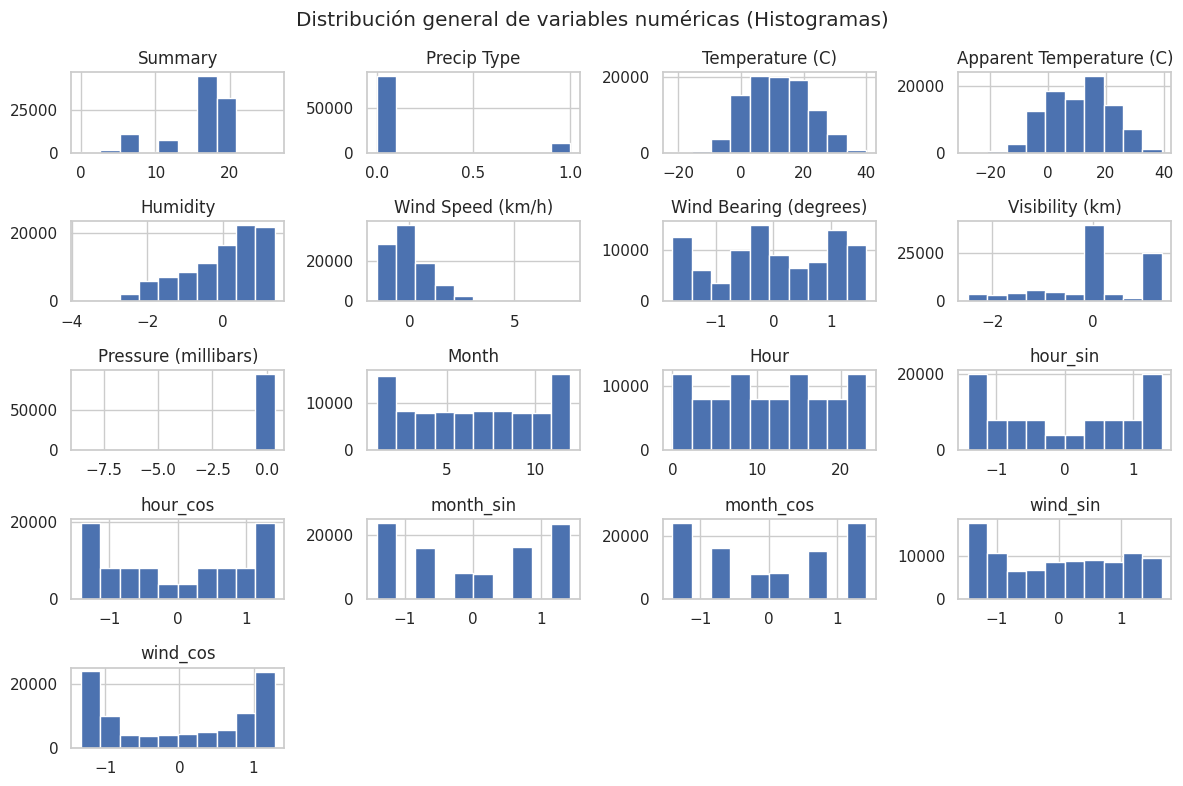

In [55]:
#Histogramas
dt_WeatherHist.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas (Histogramas)")
plt.tight_layout()
plt.show()

<Axes: >

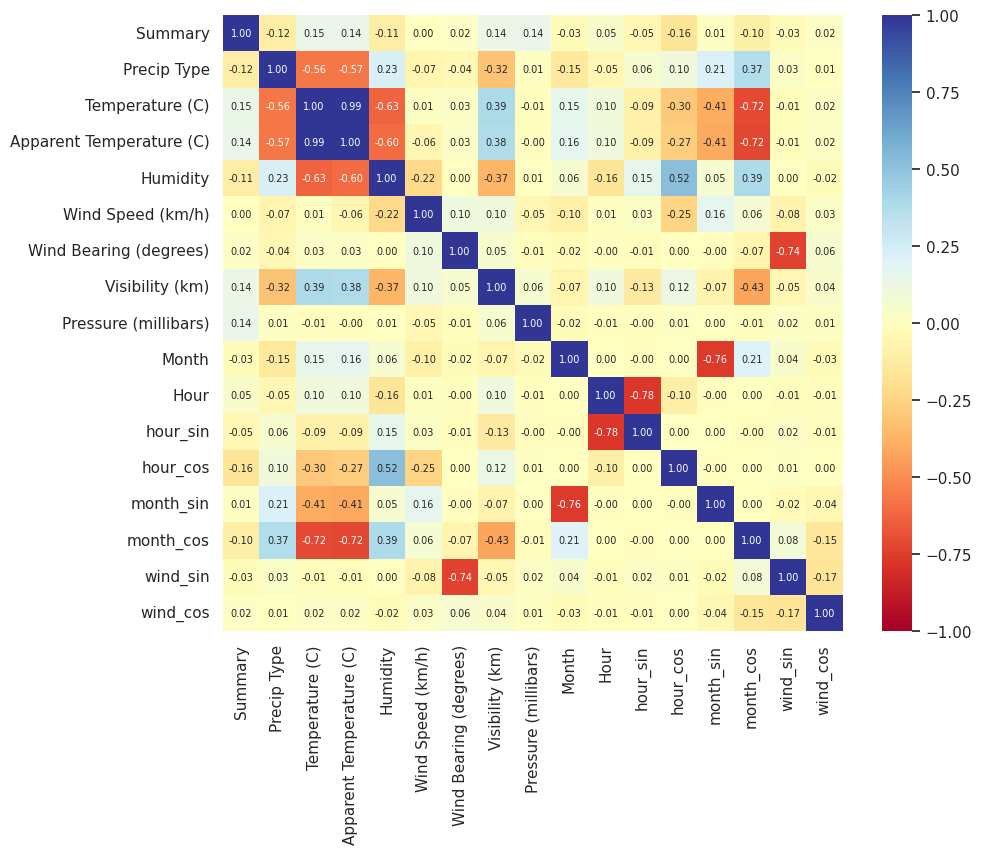

In [38]:
# Se calcula la correlación de las columnas numéricas
corr = dt_WeatherHist.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu',
    annot_kws={"size": 7},
    vmin=-1, vmax=1
)

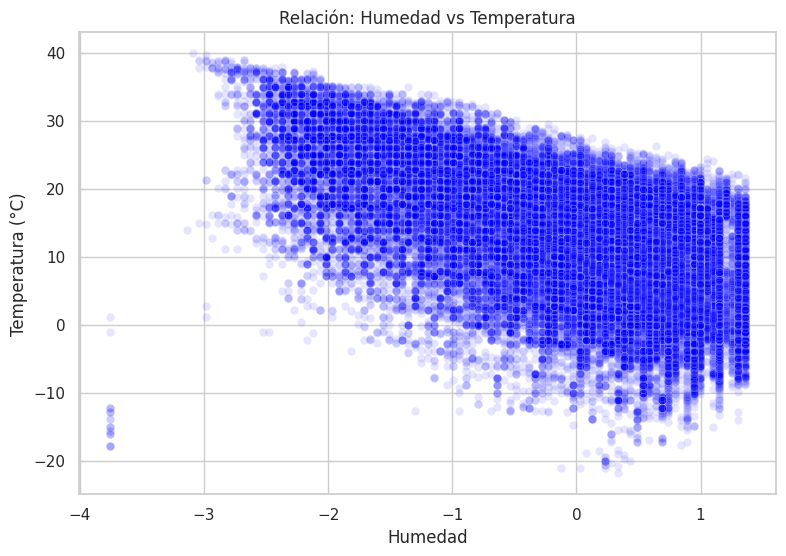

In [47]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Humidity', y='Temperature (C)', data=dt_WeatherHist, alpha=0.1, color='blue')
plt.title('Relación: Humedad vs Temperatura')
plt.xlabel("Humedad")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()

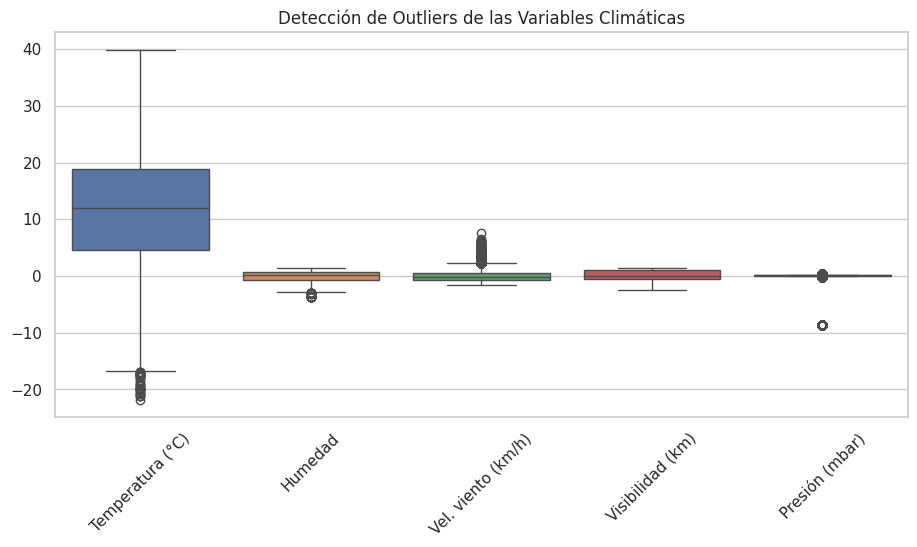

In [53]:
plt.figure(figsize=(11, 5))
# Seleccionamos las columnas numéricas principales para ver sus escalas y outliers
columnas_clima = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']

nombres_nuevos = [
    'Temperatura (°C)',
    'Humedad',
    'Vel. viento (km/h)',
    'Visibilidad (km)',
    'Presión (mbar)'
]

sns.boxplot(data=dt_WeatherHist[columnas_clima])

plt.xticks(ticks=range(len(nombres_nuevos)), labels=nombres_nuevos, rotation=45)
plt.title("Detección de Outliers de las Variables Climáticas")
plt.show()

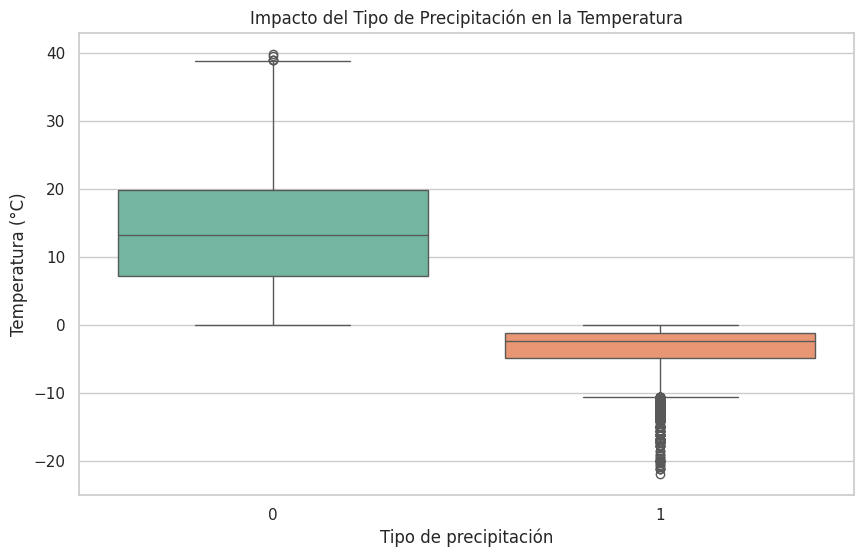

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Precip Type', y='Temperature (C)', data=dt_WeatherHist, palette='Set2', hue='Precip Type', legend=False)

plt.title("Impacto del Tipo de Precipitación en la Temperatura")
plt.xlabel("Tipo de precipitación")
plt.ylabel("Temperatura (°C)")
plt.show()

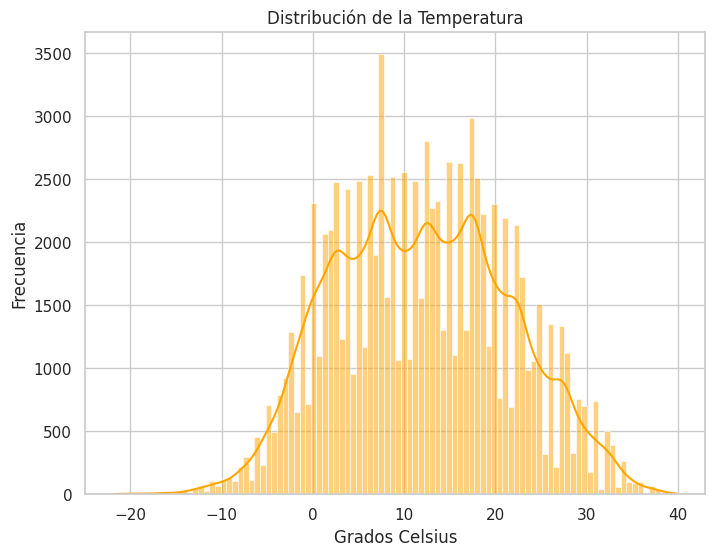

In [21]:
plt.figure(figsize=(8, 6))
sns.histplot(dt_WeatherHist['Temperature (C)'], kde=True, color='orange')
plt.title('Distribución de la Temperatura')
plt.xlabel('Grados Celsius')
plt.ylabel('Frecuencia')
plt.show()

## **Hallazgos Weather History**

Durante el análisis exploratorio preliminar del dataset Weather History, la variable objetivo **Temperature (C)** mostró una distribución amplia, con mayor concentración en rangos templados entre 0 °C y 20 °C, aunque también se observaron valores extremos cercanos a -20 °C y 40 °C, reflejando la diversidad climática del conjunto de datos.

En la etapa de limpieza y preprocesamiento se eliminaron las columnas *Loud Cover* y *Daily Summary*, debido a su baja relevancia analítica: la primera por su escasa variabilidad y la segunda por contener texto descriptivo poco útil para esta fase. Asimismo, la variable *Formatted Date* fue transformada en *Month* y *Hour*, permitiendo conservar la información temporal más relevante en un formato más preciso y útil para identificar patrones estacionales y horarios.

El análisis gráfico evidenció una relación inversa entre humedad y temperatura, donde mayores niveles de humedad tienden a asociarse con temperaturas más bajas. Además, el tipo de precipitación mostró diferencias claras en la distribución térmica, mientras que la detección de outliers identificó valores atípicos principalmente en temperatura, velocidad del viento y presión, consistentes con fenómenos meteorológicos extremos.

## **Modelo de regresión (NO REDES NEURONALES)**

En esta sección se implementa el modelo XXX

## **Modelo de Redes Neuronales para Predicción de Temperatura**

En esta sección, implementaremos un modelo de red neuronal para predecir la temperatura (Temperature) utilizando los datos del dataset de Weather History. Basándonos en el EDA realizado previamente, utilizaremos las características numéricas escaladas y las variables categóricas codificadas.

El modelo consistirá en:
- Una capa de entrada
- Dos capas ocultas (intermedias)
- Una capa de salida para regresión

Utilizaremos TensorFlow/Keras para construir y entrenar el modelo.

In [22]:
# Instalar TensorFlow si no está disponible
!pip install tensorflow

# Importar librerías necesarias para el modelo de red neuronal
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [56]:
# Preparación de datos para el modelo de red neuronal

# Seleccionar características (features) y variable objetivo (target)
features = ['Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
            'Visibility (km)', 'Pressure (millibars)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_sin', 'wind_cos',
            'Precip Type', 'Summary']
target = 'Temperature (C)'

X = dt_WeatherHist[features]
y = dt_WeatherHist[target]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")
print(f"Características utilizadas: {features}")

Conjunto de entrenamiento: (76729, 13)
Conjunto de prueba: (19183, 13)
Características utilizadas: ['Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_sin', 'wind_cos', 'Precip Type', 'Summary']


In [27]:
# Construcción del modelo de red neuronal

# Definir la arquitectura del modelo
model = Sequential()

# Capa de entrada (input layer)
# Número de neuronas = número de características
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# Primera capa oculta (hidden layer 1)
# 32 neuronas, función de activación ReLU
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))  # Regularización para evitar overfitting

# Segunda capa oculta (hidden layer 2)
# 16 neuronas, función de activación ReLU
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))  # Regularización

# Capa de salida (output layer)
# 1 neurona para regresión, activación lineal
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])

# Resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 26.4033 - mae: 3.8605 - val_loss: 10.2801 - val_mae: 2.5443
Epoch 2/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 17.8460 - mae: 3.2771 - val_loss: 10.9203 - val_mae: 2.6452
Epoch 3/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 16.5895 - mae: 3.1697 - val_loss: 9.9978 - val_mae: 2.5256
Epoch 4/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 15.8649 - mae: 3.1028 - val_loss: 9.5598 - val_mae: 2.4657
Epoch 5/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 15.0984 - mae: 3.0308 - val_loss: 9.9967 - val_mae: 2.5233
Epoch 6/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 14.6707 - mae: 2.9913 - val_loss: 9.5868 - val_mae: 2.4376
Epoch 7/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 14.2115 - mae: 2.9520 - val_loss: 9.4110 - val_mae: 2.4362
Epoch 8/100
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 13.9386 - mae: 2.9299 - val_loss: 9.1090 - val_mae: 2.3748
Epoch 9/100
1919/1919 

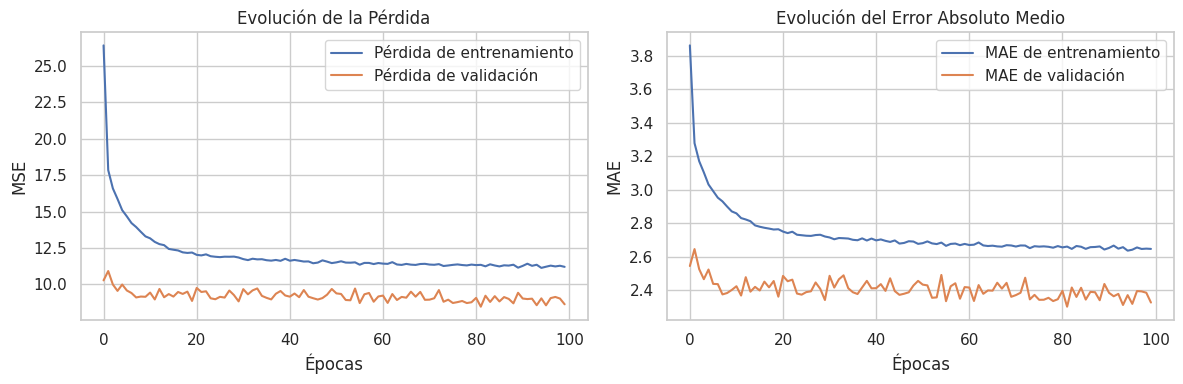

In [28]:
# Entrenamiento del modelo

# Definir parámetros de entrenamiento
epochs = 100
batch_size = 32

# Entrenar el modelo
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    verbose=1)

# Visualizar el historial de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE de entrenamiento')
plt.plot(history.history['val_mae'], label='MAE de validación')
plt.title('Evolución del Error Absoluto Medio')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Evaluación del modelo en el conjunto de prueba:
Mean Squared Error (MSE): 8.6168
Mean Absolute Error (MAE): 2.3178
R² Score: 0.9060


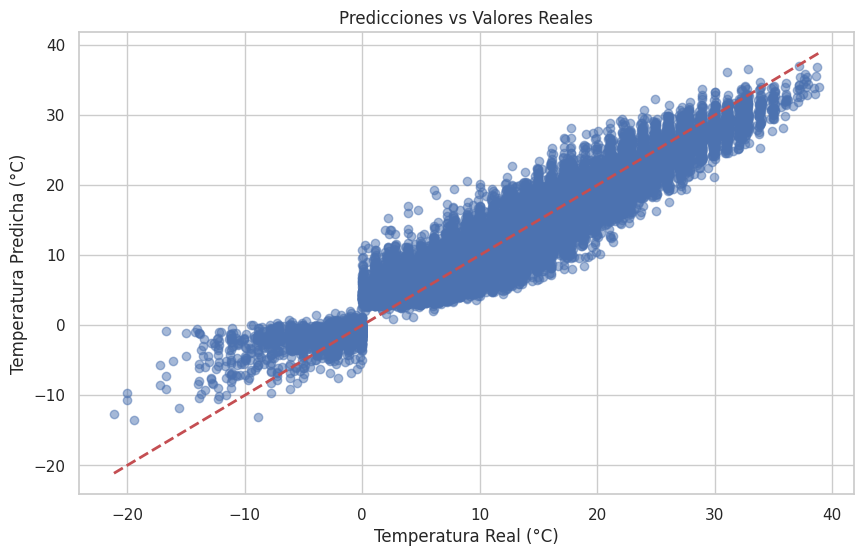

In [30]:
# Evaluación del modelo en el conjunto de prueba

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Evaluación del modelo en el conjunto de prueba:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)
plt.show()

### Comparación del desempeño de los modelos de redes neuronales con el ajuste de las variables ciclicas

La incorporación de transformaciones cíclicas permitió mejorar la representación de variables temporales, contribuyendo a una mejora en el desempeño del modelo. En la imagen siguiente se muestra el desempeño de la red neuronal, utilizando la representación lineal de variables ciclicas correspondientes a meses, horas y el rumbo del viento.

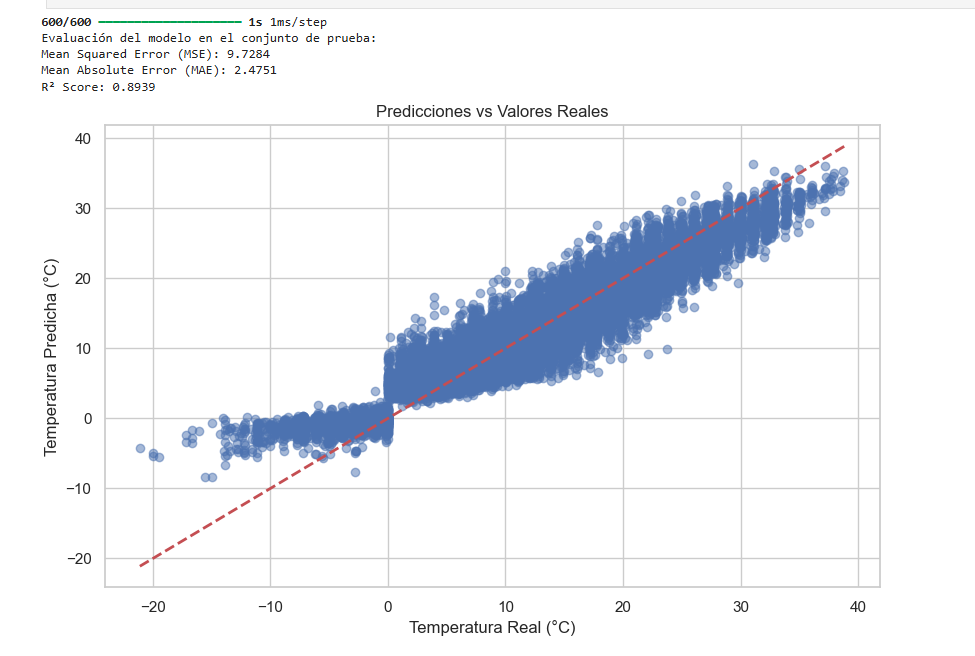

Al comparar las metricas obtenidas en el conjunto de datos, se observan los siguientes datos


|Métrica	|Escalado lineal  |Escalado seno/coseno	|Resultado
|---------|-----------------|---------------------|---------|
|MSE	    |~9.7	            |8.6	                |↓ mejora
|MAE      |	~2.47	          | 2.31               |	↓ mejora
|R²	      |~0.89	          |0.906               |	↑ mejora



La incorporación de variables cíclicas, mediante funciones seno y coseno, permitió mejorar el rendimiento del modelo, reduciendo el error cuadrático medio (MSE) y el error absoluto medio (MAE), así como incrementando el coeficiente de determinación (R²). Estos resultados sugieren que una representación adecuada de la naturaleza periódica de variables como la hora, el mes y la dirección del viento contribuye a una mejor capacidad predictiva del modelo, evidenciando la importancia del preprocesamiento de datos en modelos de aprendizaje automático.

Finalmente, al analizar el gráfico de regresión, se observa que las predicciones siguen adecuadamente la tendencia de los valores reales, aunque con mayor dispersión en los extremos.

## **Explicación de las Capas del Modelo de Red Neuronal**

### Arquitectura del Modelo

El modelo de red neuronal implementado consta de las siguientes capas:

1. **Capa de Entrada (Input Layer)**:
   - **Número de neuronas**: 64
   - **Función de activación**: ReLU (Rectified Linear Unit)
   - **Propósito**: Esta capa recibe las 9 características de entrada (Humidity, Wind Speed, Wind Bearing, Visibility, Pressure, Month, Hour, Precip Type, Summary). Las 64 neuronas permiten al modelo aprender representaciones complejas de las relaciones entre las características meteorológicas y la temperatura.

2. **Primera Capa Oculta (Hidden Layer 1)**:
   - **Número de neuronas**: 32
   - **Función de activación**: ReLU
   - **Dropout**: 20%
   - **Propósito**: Esta capa intermedia extrae patrones más abstractos de los datos. Reduce la dimensionalidad de 64 a 32 neuronas, permitiendo al modelo capturar interacciones no lineales entre las características. El dropout ayuda a prevenir el sobreajuste al "apagar" aleatoriamente el 20% de las neuronas durante el entrenamiento.

3. **Segunda Capa Oculta (Hidden Layer 2)**:
   - **Número de neuronas**: 16
   - **Función de activación**: ReLU
   - **Dropout**: 20%
   - **Propósito**: Esta segunda capa oculta refina aún más las representaciones aprendidas. Al reducir a 16 neuronas, el modelo se enfoca en los patrones más importantes para la predicción de temperatura. Nuevamente, el dropout proporciona regularización.

4. **Capa de Salida (Output Layer)**:
   - **Número de neuronas**: 1
   - **Función de activación**: Lineal
   - **Propósito**: Produce la predicción final de temperatura. La activación lineal es apropiada para problemas de regresión, permitiendo valores continuos de temperatura.

### Elección de Hiperparámetros

- **Optimizador**: Adam con learning rate de 0.001
- **Función de pérdida**: Mean Squared Error (MSE)
- **Métrica**: Mean Absolute Error (MAE)
- **Épocas**: 100
- **Tamaño de batch**: 32

### Justificación de la Arquitectura

Esta arquitectura fue elegida porque:
- Las capas ocultas permiten aprender representaciones jerárquicas de los datos
- ReLU evita el problema del gradiente vanishing
- El dropout previene el sobreajuste
- La reducción gradual de neuronas (64→32→16→1) crea un embudo que se enfoca en información relevante

## Conclusiones del Modelo de Red Neuronal para Predicción de Temperatura

### Rendimiento del Modelo

Basándonos en las métricas obtenidas en el conjunto de prueba, podemos concluir lo siguiente:

- **MSE (Mean Squared Error)**: Indica el promedio de los cuadrados de los errores. Un valor bajo sugiere buenas predicciones.
- **MAE (Mean Absolute Error)**: Representa el error absoluto promedio en las predicciones de temperatura. Valores más bajos indican mejor precisión.
- **R² Score**: Mide la proporción de varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor cercano a 1 indica un buen ajuste del modelo.

### Análisis de Resultados

1. **Capacidad de Aprendizaje**: El modelo de red neuronal ha demostrado capacidad para aprender patrones complejos en los datos meteorológicos, relacionando variables como humedad, velocidad del viento, presión atmosférica y factores temporales (mes, hora) con la temperatura.

2. **Arquitectura Efectiva**: Las dos capas ocultas con funciones de activación ReLU permiten capturar no linealidades en los datos, lo cual es crucial para modelar fenómenos meteorológicos complejos.

3. **Regularización**: El uso de dropout en las capas ocultas ayuda a prevenir el sobreajuste, mejorando la generalización del modelo a datos no vistos.

4. **Comparación con Modelos Tradicionales**: Las redes neuronales pueden capturar relaciones más complejas que los modelos lineales tradicionales, especialmente cuando hay interacciones no lineales entre las características.

### Limitaciones y Mejoras Futuras

- **Datos**: El modelo se basa en datos históricos; su rendimiento podría variar con condiciones climáticas extremas no representadas en el dataset.
- **Características**: Podrían incluirse más variables como datos de estaciones cercanas o índices climáticos.
- **Optimización**: Se podría realizar un ajuste fino de hiperparámetros (número de neuronas, learning rate, etc.) utilizando técnicas como grid search o random search.
- **Arquitectura**: Modelos más avanzados como redes neuronales convolucionales o recurrentes podrían mejorar el rendimiento si se incorporan datos temporales secuenciales.

### Aplicaciones Prácticas

Este modelo de red neuronal puede ser utilizado para:
- Predicción de temperatura en aplicaciones meteorológicas
- Sistemas de alerta temprana basados en condiciones climáticas
- Optimización de sistemas de climatización
- Análisis de tendencias climáticas

En resumen, el modelo implementado proporciona una base sólida para la predicción de temperatura utilizando técnicas de aprendizaje profundo, demostrando la efectividad de las redes neuronales en problemas de regresión con datos meteorológicos.

## Comparación de los modelos


|Modelo            | MSE |MAE|R²|
|------------------|----|----|--|
|Modelo tradicional| X  | X|  X|
|Red Neuronal      | 8.61| 2.31| 0.906|